In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

df = pd.read_csv('healthcare-dataset-stroke-data.csv')

# drop id, format bmi, remove 'Other' gender
df = df.drop(columns=['id'])
df['bmi'] = pd.to_numeric(df['bmi'], errors='coerce')
df = df[df['gender'] != 'Other'].copy()

X = df.drop('stroke', axis=1)
y = df['stroke']

# split first to avoid data leakage
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  163
smoking_status         0
stroke                 0
dtype: int64
               age  avg_glucose_level          bmi
count  4087.000000        4087.000000  3924.000000
mean     43.259369         105.895087    28.881957
std      22.642243          44.676845     7.895163
min       0.080000          55.220000    10.300000
25%      25.000000          77.455000    23.500000
50%      45.000000          91.890000    28.100000
75%      61.000000         114.035000    33.100000
max      82.000000         271.740000    97.600000


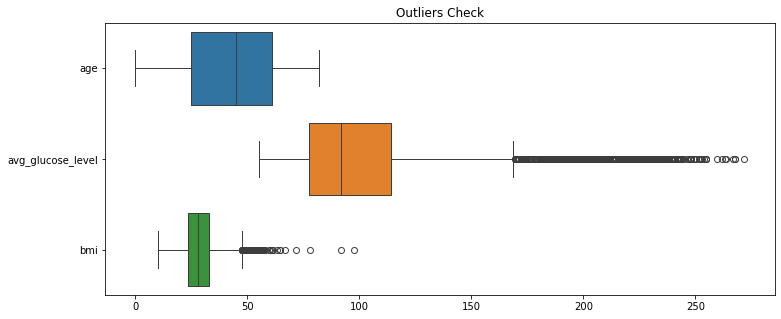

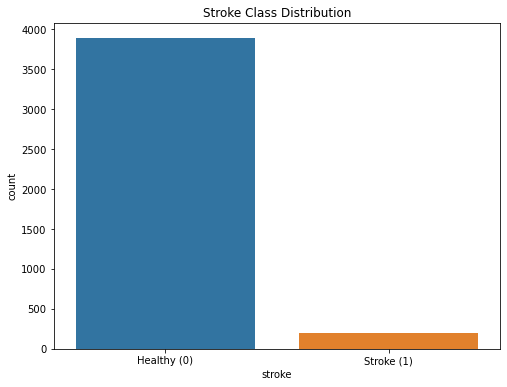

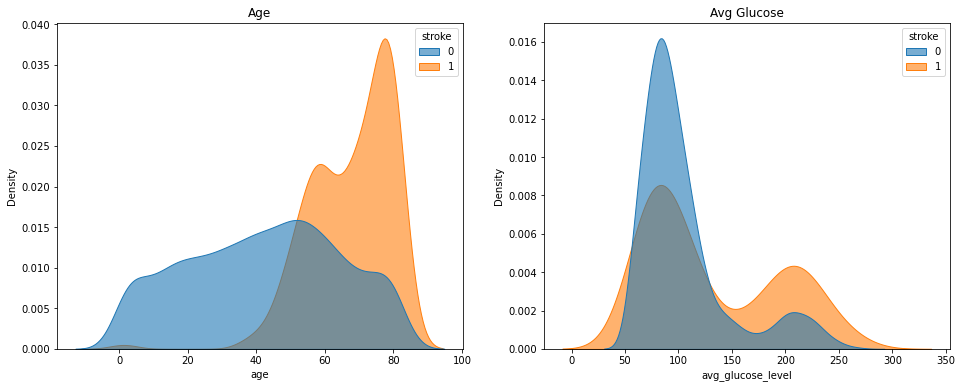

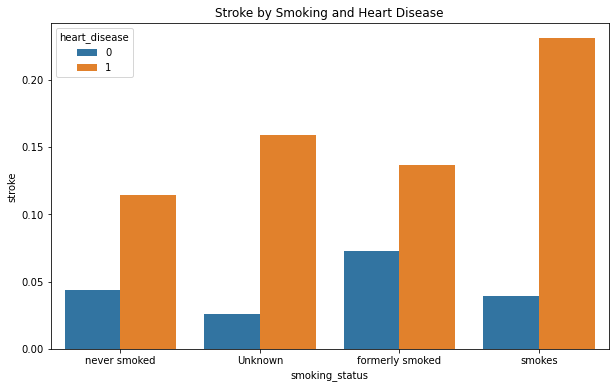

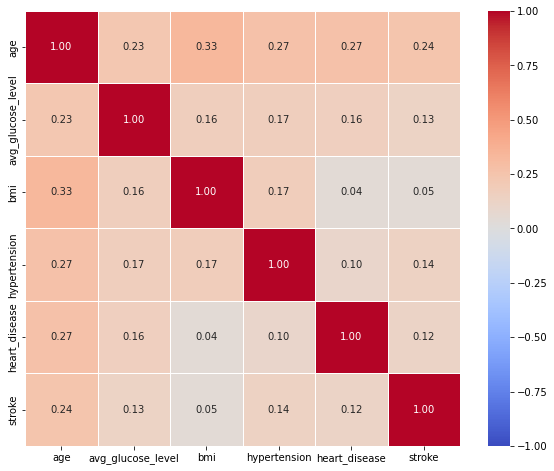

In [2]:
# eda on training set only
df_train_eda = pd.concat([X_train, y_train], axis=1)

# check missing values
print(df_train_eda.isnull().sum())

# summary statistics for numerical features
print(df_train_eda[['age', 'avg_glucose_level', 'bmi']].describe())

# boxplots for outliers
plt.figure(figsize=(12, 5))
sns.boxplot(data=df_train_eda[['age', 'avg_glucose_level', 'bmi']], orient="h")
plt.title('Outliers Check')
plt.show()

# stroke distribution
plt.figure(figsize=(8, 6))
sns.countplot(data=df_train_eda, x='stroke', hue='stroke', legend=False)
plt.xticks(ticks=[0, 1], labels=['Healthy (0)', 'Stroke (1)'])
plt.title('Stroke Class Distribution')
plt.show()

# age and glucose kde
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.kdeplot(data=df_train_eda, x='age', hue='stroke', fill=True, common_norm=False, ax=axes[0], alpha=0.6)
axes[0].set_title('Age')
sns.kdeplot(data=df_train_eda, x='avg_glucose_level', hue='stroke', fill=True, common_norm=False, ax=axes[1], alpha=0.6)
axes[1].set_title('Avg Glucose')
plt.show()

# smoking, heart disease and stroke
plt.figure(figsize=(10, 6))
sns.barplot(data=df_train_eda, x='smoking_status', y='stroke', hue='heart_disease', errorbar=None)
plt.title('Stroke by Smoking and Heart Disease')
plt.show()

# correlation heatmap
num_cols = ['age', 'avg_glucose_level', 'bmi', 'hypertension', 'heart_disease', 'stroke']
plt.figure(figsize=(10, 8))
sns.heatmap(df_train_eda[num_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, square=True, linewidths=1)
plt.show()

In [3]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler

# knn imputation for bmi
X_train_tmp = X_train.copy()
X_test_tmp = X_test.copy()
X_train_tmp['gender_num'] = X_train_tmp['gender'].map({'Male': 0, 'Female': 1})
X_test_tmp['gender_num'] = X_test_tmp['gender'].map({'Male': 0, 'Female': 1})

imputer = KNNImputer(n_neighbors=5)
impute_features = ['age', 'gender_num', 'avg_glucose_level', 'bmi']

# fit on train, transform both
imputer.fit(X_train_tmp[impute_features])
X_train['bmi'] = imputer.transform(X_train_tmp[impute_features])[:, 3]
X_test['bmi'] = imputer.transform(X_test_tmp[impute_features])[:, 3]

# one-hot encoding
categorical_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
X_train_encoded = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

# align columns in case test set misses some categories
X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

# standard scaling
scaler = StandardScaler()
num_features = ['age', 'avg_glucose_level', 'bmi']

X_train_encoded[num_features] = scaler.fit_transform(X_train_encoded[num_features])
X_test_encoded[num_features] = scaler.transform(X_test_encoded[num_features])

In [4]:
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# oversample minority class
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_encoded, y_train)

# weighted lr (original data)
model_weighted = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
model_weighted.fit(X_train_encoded, y_train)

# smote lr
model_smote = LogisticRegression(random_state=42, max_iter=1000)
model_smote.fit(X_train_smote, y_train_smote)

# rf
rf_model = RandomForestClassifier(random_state=42, n_estimators=100, n_jobs=-1)
rf_model.fit(X_train_smote, y_train_smote)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


--- Weighted LR (Threshold: 0.5) ---
              precision    recall  f1-score   support

           0       0.99      0.73      0.84       972
           1       0.13      0.80      0.23        50

    accuracy                           0.74      1022
   macro avg       0.56      0.77      0.54      1022
weighted avg       0.94      0.74      0.81      1022

PR-AUC: 0.2527

--- SMOTE LR (Threshold: 0.5) ---
              precision    recall  f1-score   support

           0       0.98      0.76      0.86       972
           1       0.14      0.74      0.23        50

    accuracy                           0.76      1022
   macro avg       0.56      0.75      0.54      1022
weighted avg       0.94      0.76      0.83      1022

PR-AUC: 0.1987

--- Random Forest (Threshold: 0.1) ---
              precision    recall  f1-score   support

           0       0.99      0.61      0.75       972
           1       0.10      0.84      0.18        50

    accuracy                           0

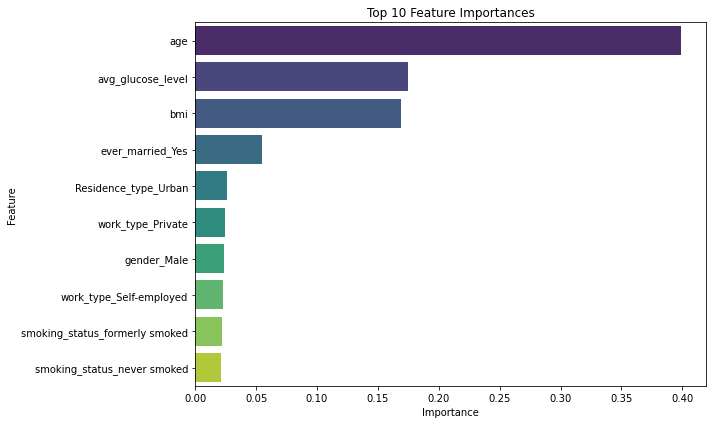


--- Odds Ratios ---


,Feature,Odds_Ratio
0,age,6.578
10,work_type_children,2.439
1,hypertension,1.875
14,smoking_status_smokes,1.333
3,avg_glucose_level,1.232
11,Residence_type_Urban,1.190
2,heart_disease,1.157
12,smoking_status_formerly smoked,1.096
4,bmi,1.069
8,work_type_Private,1.027


In [11]:
from sklearn.metrics import classification_report, precision_recall_curve, auc

def evaluate_model(model, X_test_data, y_test_data, name, threshold=0.5):
    y_proba = model.predict_proba(X_test_data)[:, 1]
    y_pred_custom = (y_proba > threshold).astype(int)
    
    precision, recall, _ = precision_recall_curve(y_test_data, y_proba)
    pr_auc = auc(recall, precision)
    
    print(f"--- {name} (Threshold: {threshold}) ---")
    print(classification_report(y_test_data, y_pred_custom, zero_division=0))
    print(f"PR-AUC: {pr_auc:.4f}\n")

# evaluate
evaluate_model(model_weighted, X_test_encoded, y_test, "Weighted LR")
evaluate_model(model_smote, X_test_encoded, y_test, "SMOTE LR")
evaluate_model(rf_model, X_test_encoded, y_test, "Random Forest", threshold=0.1)

# feature importance
feature_importance_df = pd.DataFrame({
    'Feature': X_train_encoded.columns, 
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
# added palette='viridis' for better visualization
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), hue='Feature', palette='viridis', legend=False)
plt.title('Top 10 Feature Importances')
plt.tight_layout()
plt.show()

# odds ratios
odds_ratios = np.exp(model_weighted.coef_[0])
or_df = pd.DataFrame({
    'Feature': X_train_encoded.columns, 
    'Odds_Ratio': odds_ratios
}).sort_values(by='Odds_Ratio', ascending=False)

# format values to 3 decimal places for cleaner display
or_df['Odds_Ratio'] = or_df['Odds_Ratio'].round(3)

print("\n--- Odds Ratios ---")
display(or_df.head(10))

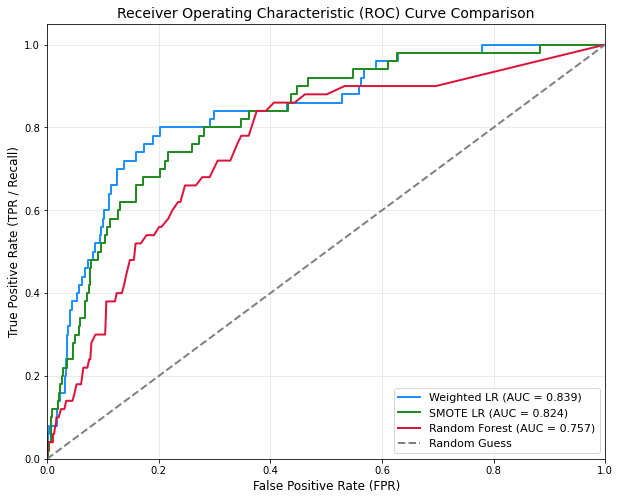

In [15]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

# define a helper function to plot the ROC curve
def plot_roc_curve(model, X_test_data, y_test_data, name, color):
    # Get the predicted probabilities for the positive class
    y_proba = model.predict_proba(X_test_data)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test_data, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

# plot the ROC curves for the three models
plot_roc_curve(model_weighted, X_test_encoded, y_test, "Weighted LR", "dodgerblue")
plot_roc_curve(model_smote, X_test_encoded, y_test, "SMOTE LR", "forestgreen")
plot_roc_curve(rf_model, X_test_encoded, y_test, "Random Forest", "crimson")

# plot the diagonal line representing a random guess
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Guess')

# chart formatting
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR / Recall)', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve Comparison', fontsize=14)
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.show()